The second edition of *Think Complexity* is available from [Bookshop.org](https://bookshop.org/a/98697/9781492040200) and [Amazon](https://amzn.to/3wPN0SJ) (those are affiliate links). If you are enjoying the free, online version, consider [buying me a coffee](https://buymeacoffee.com/allendowney).

# Physical modeling

The cellular automatons we have seen so far are not physical models; that is, they are not intended to describe systems in the real world. But some CAs are intended as physical models.

In this chapter we consider a CA that models chemicals that diffuse (spread out) and react with each other, which is a process Alan Turing proposed to explain how some animal patterns develop.

And we'll experiment with a CA that models percolation of liquid through porous material, like water through coffee grounds. This model is the first of several models that exhibit **phase change** behavior and **fractal geometry**, and I'll explain what both of those mean.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkComplexity/blob/v3/soln/chap07.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/utils.py')
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/Cell1D.py')
download('https://github.com/AllenDowney/ThinkComplexity/raw/v3/nb/Cell2D.py')

In [3]:
from utils import decorate, savefig
# make a directory for figures
!mkdir -p figs

## Diffusion

In 1952 Alan Turing published a paper called "The chemical basis of morphogenesis", which describes the behavior of systems involving two chemicals that diffuse in space and react with each other. He showed that these systems produce a wide range of patterns, depending on the diffusion and reaction rates, and conjectured that systems like this might be an important mechanism in biological growth processes, particularly the development of animal coloration patterns.

Turing's model is based on differential equations, but it can be implemented using a cellular automaton.

Before we get to Turing's model, we'll start with something simpler: a diffusion system with just one chemical. We'll use a 2-D CA where the state of each cell is a continuous quantity (usually between 0 and 1) that represents the concentration of the chemical.

We'll model the diffusion process by comparing each cell with the average of its neighbors. If the concentration of the center cell exceeds the neighborhood average, the chemical flows from the center to the neighbors. If the concentration of the center cell is lower, the chemical flows the other way.

The kernel in the following class computes the difference between each cell and the average of its neighbors. In `step`, we use `correlate2d` to apply this kernel to each cell in the array, and we use a diffusion constant, `r`, that relates the difference in concentration to the rate of flow.

In [4]:
from scipy.signal import correlate2d
from Cell2D import Cell2D, draw_array


class Diffusion(Cell2D):
    """Diffusion Cellular Automaton."""
    
    kernel = np.array([[0, 1, 0],
                       [1,-4, 1],
                       [0, 1, 0]])

    def __init__(self, n, r=0.1):
        """Initializes the attributes.

        n: number of rows
        r: diffusion rate constant
        """
        self.r = r
        self.array = np.zeros((n, n), float)
        
    def add_cells(self, row, col, *strings):
        """Adds cells at the given location.

        row: top row index
        col: left col index
        strings: list of strings of 0s and 1s
        """
        for i, s in enumerate(strings):
            self.array[row+i, col:col+len(s)] = np.array([int(b) for b in s])

    def step(self):
        """Executes one time step."""
        c = correlate2d(self.array, self.kernel, mode='same')
        self.array += self.r * c
        
    def draw(self):
        """Draws the cells."""
        draw_array(self.array, cmap='Reds')

Here's a simple example starting with an "island" of material in the middle.

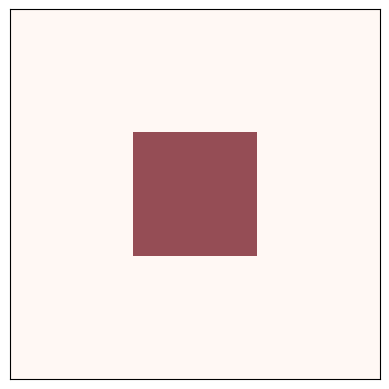

In [5]:
diff = Diffusion(n=9, r=0.1)
diff.add_cells(3, 3, '111', '111', '111')
diff.draw()

And here's how it behaves over time: the "material" spreads out until the level is equal on the whole array.

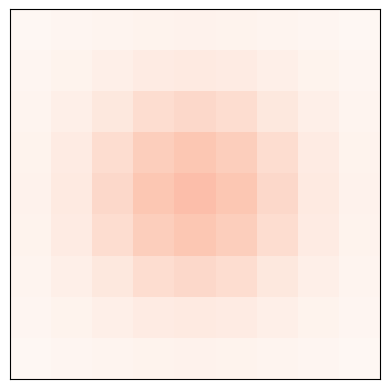

In [6]:
diff.animate(frames=20, interval=0.1)

The following figure shows results for a CA with size `n=9`, diffusion constant `r=0.1`, and initial concentration 0 everywhere except for an "island" in the middle. The figure shows the starting configuration and the state of the CA after 5 and 10 steps.

In [7]:
from utils import three_frame

diff = Diffusion(n=9, r=0.1)
diff.add_cells(3, 3, '111', '111', '111')
three_frame(diff, [0, 5, 10])

savefig('figs/chap07-1')

Saving figure to file figs/chap07-1


The chemical spreads from the center outward, continuing until the concentration is the same everywhere.

## Reaction-diffusion

Now let's add a second chemical. I'll define a new object, `ReactionDiffusion`, that contains two arrays, one for each chemical. To set up the initial conditions, we'll use `add_island`, which adds an island of higher concentration in the middle of an array:

In [8]:
def add_island(a, height=0.1):
    """Adds an island in the middle of the array.
            
    height: height of the island
    """
    n, m = a.shape
    radius = min(n, m) // 20
    i = n//2
    j = m//2
    a[i-radius:i+radius, j-radius:j+radius] += height

The radius of the island is one twentieth of `n` or `m`, whichever is smaller. The height of the island is `height`, with the default value 0.1.

Here's the definition of `ReactionDiffusion`. Following [Sims](http://www.karlsims.com/rd.html), I'm using a kernel that includes the diagonal elements.  They have lower weights because they are farther from the center cell.

In [9]:
class ReactionDiffusion(Diffusion):
    """Reaction-Diffusion Cellular Automaton."""

    kernel = np.array([[.05, .2, .05],
                       [ .2, -1, .2],
                       [.05, .2, .05]])

    def __init__(self, n, params, noise=0.1):
        """Initializes the attributes.

        n: number of rows
        params: tuple of (Da, Db, f, k)
        """        
        self.params = params
        self.array1 = np.ones((n, n), dtype=float)
        self.array2 = noise * np.random.random((n, n))
        add_island(self.array2)
        
    def step(self):
        """Executes one time step."""
        A = self.array1
        B = self.array2
        ra, rb, f, k = self.params

        options = dict(mode='same', boundary='wrap')

        cA = correlate2d(A, self.kernel, **options)
        cB = correlate2d(B, self.kernel, **options)
        reaction = A * B**2
        self.array1 += ra * cA - reaction + f * (1-A) 
        self.array2 += rb * cB + reaction - (f+k) * B
        
    def loop100(self):
        self.loop(100)
        
    def draw(self):
        """Draws the cells."""
        options = dict(interpolation='bicubic', 
                       vmin=None, vmax=None)
        draw_array(self.array1, cmap='Reds', **options)
        draw_array(self.array2, cmap='Blues', **options)

`n` is the number of rows and columns in the arrays. `params` is a tuple of parameters, which I explain below.

`array1` represents the concentration of the first chemical, `A`; the NumPy function `ones` initializes it to 1 everywhere. The data type `float` indicates that the elements of `A` are floating-point values.

`array2` represents the concentration of `B`, which is initialized with random values between 0 and `noise`, which is 0.1 by default. Then `add_island` adds an island of higher concentration in the middle.

`step` updates the arrays. The parameters are

`ra`:

:   The diffusion rate of `A` (analogous to `r` in the previous section).

`rb`:

:   The diffusion rate of `B`. In most versions of this model, `rb` is about half of `ra`.

`f`:

:   The "feed" rate, which controls how quickly `A` is added to the system.

`k`:

:   The "kill" rate, which controls how quickly `B` is removed from the system.

Now let's look more closely at the update statements:

```
reaction = A * B**2
self.array1 += ra * cA - reaction + f * (1-A) 
self.array2 += rb * cB + reaction - (f+k) * B
```

The arrays `cA` and `cB` are the result of applying a diffusion kernel to `A` and `B`. Multiplying by `ra` and `rb` yields the rate of diffusion into or out of each cell.

The term `A * B**2` represents the rate that `A` and `B` react with each other. Assuming that the reaction consumes `A` and produces `B`, we subtract this term in the first equation and add it in the second.

The term `f * (1-A)` determines the rate that `A` is added to the system. Where `A` is near 0, the maximum feed rate is `f`. Where `A` approaches 1, the feed rate drops off to zero.

Finally, the term `(f+k) * B` determines the rate that `B` is removed from the system. As `B` approaches 0, this rate goes to zero.

In mathematical notation, `step` computes

$\Delta A = r_a \nabla^2 A - AB^2 + f (1-A) $

$\Delta B = r_b \nabla^2 B + AB^2 - (k+f) B $

where $\nabla^2$ is the Laplace operator the kernel is intended to approximate.

As long as the rate parameters are not too high, the values of `A` and `B` usually stay between 0 and 1.

`draw` shows both arrays with some transparency, so we can see where one, the other, or both, levels are high. Unlike previous CAs, the state of each cell is meant to represent a continuous quantity, so it is appropriate to interpolate.

Here's an example using `params1`.

In [10]:
params1 = 0.5, 0.25, 0.035, 0.057   # pink spots and stripes
params2 = 0.5, 0.25, 0.055, 0.062   # coral
params3 = 0.5, 0.25, 0.039, 0.065   # blue spots

rd = ReactionDiffusion(n=100, params=params1)
rd.draw()

It's a random starting condition with lots of A, a sprinkling of B everywhere, and an island of B in the middle. Here's how it evolves:

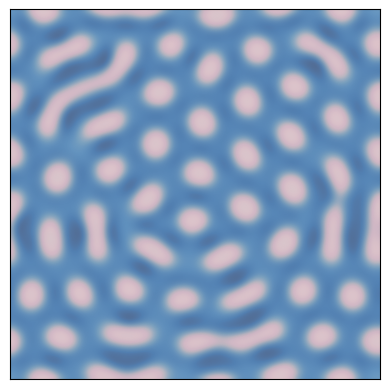

In [11]:
rd.animate(frames=50, step=rd.loop100)

With different parameters, this model can produce patterns similar to the stripes and spots on a variety of animals. In some cases, the similarity is striking, especially when the feed and kill parameters vary in space.

For all simulations in this section, `ra=0.5` and `rb=0.25`. I'll use the following function to generate figures using different parameters.

In [12]:
def make_rd(f, k, n=100):
    """Makes a ReactionDiffusion object with given parameters.
    """
    params = 0.5, 0.25, f, k
    rd = ReactionDiffusion(n, params)
    return rd

The following figure shows results with `f=0.035` and `k=0.057` after 1000, 2000, and 4000 steps, with the concentration of `A` in red and `B` in blue.

In [13]:
from utils import three_frame

def plot_rd(f, k, filename):
    """Makes a ReactionDiffusion object with given parameters.
    """
    params = 0.5, 0.25, f, k
    rd = ReactionDiffusion(100, params)

    three_frame(rd, [1000, 2000, 4000])
    
    savefig(filename)
    
plot_rd(0.035, 0.057, 'figs/chap07-2')

Saving figure to file figs/chap07-2


With these parameters, the system evolves toward a stable configuration with light spots of `A` on a dark background of `B`.

The following figure shows results with `f=0.055` and `k=0.062`, which yields a coral-like pattern of `B` on a background of `A`.

In [14]:
plot_rd(0.055, 0.062, 'figs/chap07-3')

Saving figure to file figs/chap07-3


The following figure shows results with `f=0.039` and `k=0.065`.

In [15]:
plot_rd(0.039, 0.065, 'figs/chap07-4')

Saving figure to file figs/chap07-4


These parameters produce spots of `B` that grow and divide in a process that resembles mitosis, ending with a stable pattern of equally-spaced spots.

Since 1952, observations and experiments have provided some support for Turing's conjecture. At this point it seems likely, but not yet proven, that many animal patterns are actually formed by reaction-diffusion processes of some kind.

## Percolation

Percolation is a process in which a fluid flows through a semi-porous material. Examples include oil in rock formations, water in paper, and hydrogen gas in micropores. Percolation models are also used to study systems that are not literally percolation, including epidemics and networks of electrical resistors. See <https://thinkcomplex.com/perc>.

Percolation models are often represented using random graphs like the ones we saw in Chapter 2, but they can also be represented using cellular automatons. In the next few sections we'll explore a 2-D CA that simulates percolation.

In this model:

-   Initially, each cell is either "porous" with probability `q` or "non-porous" with probability `1-q`.

-   When the simulation begins, all cells are considered "dry" except the top row, which is "wet".

-   During each time step, if a porous cell has at least one wet neighbor, it becomes wet. Non-porous cells stay dry.

-   The simulation runs until it reaches a "fixed point" where no more cells change state.

If there is a path of wet cells from the top to the bottom row, we say that the CA has a "percolating cluster".

Two questions of interest regarding percolation are (1) the probability that a random array contains a percolating cluster, and (2) how that probability depends on `q`. These questions might remind you of Chapter 2, where we considered the probability that a random graph is connected. We will see several connections between that model and this one.

I define a new class to represent a percolation model:

In [16]:
from scipy.signal import correlate2d
from Cell2D import Cell2D

class Percolation(Cell2D):
    """Percolation Cellular Automaton."""

    kernel = np.array([[0, 1, 0],
                       [1, 0, 1],
                       [0, 1, 0]])

    def __init__(self, n, q=0.5):
        """Initializes the attributes.

        n: number of rows
        q: probability of porousness
        """
        self.q = q
        self.array = np.random.choice([1, 0], (n, n), p=[q, 1-q])
        
        # fill the top row with wet cells
        self.array[0] = 5

    def step(self):
        """Executes one time step."""
        a = self.array
        c = correlate2d(a, self.kernel, mode='same')
        self.array[(a==1) & (c>=5)] = 5
        
    def num_wet(self):
        """Total number of wet cells."""
        return np.sum(self.array == 5)
    
    def bottom_row_wet(self):
        """Number of wet cells in the bottom row."""
        return np.sum(self.array[-1] == 5)
    
    def draw(self):
        """Draws the cells."""
        draw_array(self.array, cmap='Blues', vmax=5)

`n` is the number of rows and columns in the CA.

The state of the CA is stored in `array`, which is initialized using `np.random.choice` to choose 1 (porous) with probability `q`, and 0 (non-porous) with probability `1-q`.

The state of the top row is set to 5, which represents a wet cell. Using 5, rather than the more obvious 2, makes it possible to use `correlate2d` to check whether any porous cell has a wet neighbor.

The kernel defines a 4-cell "von Neumann" neighborhood; unlike the Moore neighborhood we saw in Chapter 6, it does not include the diagonals.

This kernel adds up the states of the neighbors. If any of them are wet, the result will exceed 5. Otherwise the maximum result is 4 (if all neighbors happen to be porous).

We can use this logic to write a simple, fast `step` function, which identifies porous cells, where `a==1`, that have at least one wet neighbor, where `c>=5`, and sets their state to 5, which indicates that they are wet.

The following figure shows the first few steps of a percolation model with `n=10` and `q=0.7`. Non-porous cells are white, porous cells are lightly shaded, and wet cells are dark.

In [17]:
n = 10
q = 0.7
np.random.seed(18)
perc = Percolation(n, q)

three_frame(perc, [1, 1, 1])

savefig('figs/chap07-5')

Saving figure to file figs/chap07-5


## Phase change

Now let's test whether a random array contains a percolating cluster:

In [18]:
def test_perc(perc):
    """Run a percolation model.
    
    Runs until water gets to the bottom row or nothing changes.
    
    returns: boolean, whether there's a percolating cluster
    """
    num_wet = perc.num_wet()

    while True:
        perc.step()

        if perc.bottom_row_wet():
            return True
        
        new_num_wet = perc.num_wet()
        if new_num_wet == num_wet:
            return False

        num_wet = new_num_wet

`test_perc` takes a `Percolation` object as a parameter. Each time through the loop, it advances the CA one time step. It checks the bottom row to see if any cells are wet; if so, it returns `True`, to indicate that there is a percolating cluster.

During each time step, it also computes the number of wet cells and checks whether the number increased since the last step. If not, we have reached a fixed point without finding a percolating cluster, so `test_perc` returns `False`.

Here's a small example.

In [19]:
np.random.seed(18)
perc = Percolation(n, q)
test_perc(perc)

True

And here's the animation.

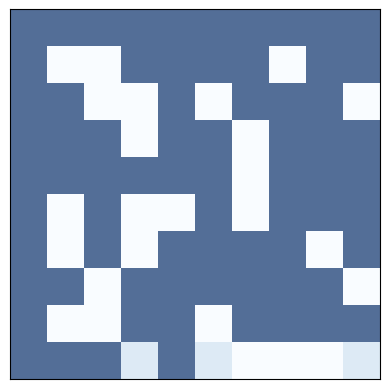

In [20]:
np.random.seed(18)
perc = Percolation(n, q)
perc.animate(frames=12, interval=0.3)

To estimate the probability of a percolating cluster, we generate many random arrays and test them:

In [21]:
def estimate_prob_percolating(n=100, q=0.5, iters=100):
    """Estimates the probability of percolating.
    
    n: int number of rows and columns
    q: probability that a cell is permeable
    iters: number of arrays to test
    
    returns: float probability
    """
    t = [test_perc(Percolation(n, q)) for i in range(iters)]
    return np.mean(t)

`estimate_prob_percolating` makes 100 `Percolation` objects with the given values of `n` and `q` and calls `test_perc` to see how many of them have a percolating cluster. The return value is the fraction that do.

When `q=0.55`, the probability of a percolating cluster is near 0.

In [22]:
fraction = estimate_prob_percolating(q=0.55)
print(fraction)

0.0


At `q=0.60`, it is about 70%.

In [23]:
fraction = estimate_prob_percolating(q=0.6)
print(fraction)

0.71


And at `q=0.65` it is near 1.

In [24]:
fraction = estimate_prob_percolating(q=0.65)
print(fraction)

1.0


This rapid transition suggests that there is a critical value of `q` near 0.6.

We can estimate the critical value more precisely using a **random walk**. Starting from an initial value of `q`, we construct a `Percolation` object and check whether it has a percolating cluster. If so, `q` is probably too high, so we decrease it. If not, `q` is probably too low, so we increase it.

Here's the code:

In [25]:
def find_critical(n=100, q=0.6, iters=100):
    """Estimate q_crit by random walk.
    
    returns: list of q that should wander around q_crit
    """
    qs = [q]
    for i in range(iters):
        perc = Percolation(n, q)
        if test_perc(perc):
            q -= 0.005
        else:
            q += 0.005
        qs.append(q)
    return qs

The result is a list of values for `q`. We can estimate the critical value, `q_crit`, by computing the mean of this list. With `n=50`, the random walk wanders around 0.59.

In [26]:
%time qs = find_critical(n=50, iters=1000)
plt.plot(qs)
decorate(xlabel='Time steps', ylabel='Estimated q_crit')
np.mean(qs)

CPU times: user 9.1 s, sys: 63 μs, total: 9.1 s
Wall time: 9.1 s


np.float64(0.5932367632367631)

Larger values of `n` don't seem to change the critical value.

In [27]:
%time qs = find_critical(n=100, iters=200)
plt.plot(qs)
decorate(xlabel='Time steps', ylabel='Estimated q_crit')
np.mean(qs)

CPU times: user 12.9 s, sys: 3.96 ms, total: 12.9 s
Wall time: 12.9 s


np.float64(0.5933830845771144)

In [28]:
%time qs = find_critical(n=200, iters=40)
plt.plot(qs)
decorate(xlabel='Time steps', ylabel='Estimated q_crit')
np.mean(qs)

CPU times: user 20.7 s, sys: 4.06 ms, total: 20.7 s
Wall time: 20.7 s


np.float64(0.5912195121951219)

In [29]:
%time qs = find_critical(n=400, iters=10)
plt.plot(qs)
decorate(xlabel='Time steps', ylabel='Estimated q_crit')
np.mean(qs)

CPU times: user 46.3 s, sys: 20 ms, total: 46.3 s
Wall time: 46.3 s


np.float64(0.5968181818181817)

The rapid change in behavior near the critical value is called a **phase change** by analogy with phase changes in physical systems, like the way water changes from liquid to solid at its freezing point.

A wide variety of systems display a common set of behaviors and characteristics when they are at or near a critical point. These behaviors are known collectively as **critical phenomena**. In the next section, we explore one of them: fractal geometry.

## Fractals

To understand fractals, we have to start with dimensions.

For simple geometric objects, dimension is defined in terms of scaling behavior. For example, if the side of a square has length $l$, its area is $l^2$. The exponent, 2, indicates that a square is two-dimensional. Similarly, if the side of a cube has length $l$, its volume is $l^3$, which indicates that a cube is three-dimensional.

More generally, we can estimate the dimension of an object by measuring some kind of size (like area or volume) as a function of some kind of linear measure (like the length of a side).

As an example, I'll estimate the dimension of a 1-D cellular automaton by measuring its area (total number of "on" cells) as a function of the number of rows.

In [30]:
from Cell1D import Cell1D, draw_ca

In [31]:
draw_ca(20)


The following figure shows three 1-D CAs like the ones we saw in Chapter 5, after 32 time steps.

In [32]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
draw_ca(20)

plt.subplot(1, 3, 2)
draw_ca(50)

plt.subplot(1, 3, 3)
draw_ca(18)

plt.tight_layout()
savefig('figs/chap07-7')

Saving figure to file figs/chap07-7


Rule 20 (left) generates a set of cells that seems like a line, so we expect it to be one-dimensional. Rule 50 (center) produces something like a triangle, so we expect it to be 2-D. Rule 18 (right) also produces something like a triangle, but the density is not uniform, so its scaling behavior is not obvious.

I'll estimate the dimension of these CAs with the following function, which counts the number of on cells after each time step. It returns a list of tuples, where each tuple contains $i$, $i^2$, and the total number of cells.

In [33]:
def count_cells(rule, n=500):
    """Create a 1-D CA and count cells.
    
    rule: int rule number
    n: number of steps
    """
    ca = Cell1D(rule, n)
    ca.start_single()
    
    res = []
    for i in range(1, n):
        cells = np.sum(ca.array)
        res.append((i, i**2, cells))
        ca.step()
        
    return res

The following function plots the results, comparing the rate of cell growth to `size` and `size**2`. And it uses `linregress` to estimate the slope of the line on a log-log scale.

In [34]:
from scipy.stats import linregress

def test_fractal(rule, ylabel='Number of Cells'):
    """Compute the fractal dimension of a rule.
    
    rule: int rule number
    ylabel: string
    """
    res = count_cells(rule)
    steps, steps2, cells = zip(*res)

    options = dict(linestyle='dashed', color='gray', alpha=0.7)
    plt.plot(steps, steps2, label='d=2', **options)
    plt.plot(steps, cells, label='rule=%d' % rule)
    plt.plot(steps, steps, label='d=1', **options)

    decorate(xscale='log', yscale='log',
             xlabel='Time Steps',
             ylabel=ylabel,
             xlim=[1, 600], loc='upper left')

    params = linregress(np.log(steps), np.log(cells))
    print(params[0])

The linear rule has dimension close to 1.

In [35]:
test_fractal(20)

1.0079212645952567


The triangular rule has dimension close to 2.

In [36]:
test_fractal(50)

1.9712808836268108


And the Sierpinski triangle has fractal dimension approximately 1.57.

In [37]:
test_fractal(18)

1.5739294411777074


The following figure shows the number of "on" cells versus the number of time steps for rules 20, 50, and 18, plotted on a log-log scale.

In [38]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
test_fractal(20)

plt.subplot(1, 3, 2)
test_fractal(50, ylabel='')

plt.subplot(1, 3, 3)
test_fractal(18, ylabel='')

savefig('figs/chap07-8')

1.0079212645952567


1.9712808836268108


1.5739294411777074
Saving figure to file figs/chap07-8


In each figure, the top dashed line shows $y = i^2$. Taking the log of both sides, we have $\log y = 2 \log i$. Since the figure is on a log-log scale, the slope of this line is 2.

Similarly, the bottom dashed line shows $y = i$. On a log-log scale, the slope of this line is 1.

Rule 20 (left) produces 3 cells every 2 time steps, so the total number of cells after $i$ steps is $y = 1.5 i$. Taking the log of both sides, we have $\log y = \log 1.5 + \log i$, so on a log-log scale, we expect a line with slope 1. In fact, the estimated slope of the line is 1.01.

Rule 50 (center) produces $i+1$ new cells during the $i$th time step, so the total number of cells after $i$ steps is $y = i^2 + i$. If we ignore the second term and take the log of both sides, we have $\log y \sim 2 \log i$, so as $i$ gets large, we expect to see a line with slope 2. In fact, the estimated slope is 1.97.

Finally, for Rule 18 (right), the estimated slope is about 1.57, which is clearly not 1, 2, or any other integer. This suggests that the pattern generated by Rule 18 has a "fractional dimension"; that is, it is a fractal.

Mathematically, the fractal dimension is supposed to be:

In [39]:
np.log(3) / np.log(2)

np.float64(1.5849625007211563)

This way of estimating a fractal dimension is called **box-counting**. For more about it, see <https://thinkcomplex.com/box>.

## Fractals and Percolation Models

Now let's get back to percolation models. Near the critical point, the cluster of wet cells forms a fractal.  We can see that visually in these examples:

In [40]:
np.random.seed(22)
perc1 = Percolation(n=100, q=0.6)
flag = test_perc(perc1)
print(flag)
perc1.draw()

False


/home/downey/ThinkComplexity/soln/Cell2D.py:100: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.axis([0, m, 0, n])
/home/downey/ThinkComplexity/soln/Cell2D.py:100: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.axis([0, m, 0, n])


In [41]:
np.random.seed(22)
perc2 = Percolation(n=200, q=0.6)
flag = test_perc(perc2)
print(flag)
perc2.draw()

False


In [42]:
np.random.seed(22)
perc3 = Percolation(n=300, q=0.6)
flag = test_perc(perc3)
print(flag)
perc3.draw()

True


The following figure shows clusters of wet cells in percolation simulations with `q=0.6` and `n=100`, `200`, and `300`.

In [43]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
perc1.draw()

plt.subplot(1, 3, 2)
perc2.draw()

plt.subplot(1, 3, 3)
perc3.draw()

plt.tight_layout()
savefig('figs/chap07-6')

Saving figure to file figs/chap07-6


Informally, they resemble fractal patterns seen in nature and in mathematical models.

To estimate their fractal dimension, we can run CAs with a range of sizes, count the number of wet cells in each percolating cluster, and then see how the cell counts scale as we increase the size of the array.

The following function takes a sequence of sizes and the proportion of porous cells, `q`. It runs the percolation model with each of the sizes and checks whether it percolates from top to bottom.

In [44]:
from scipy.stats import linregress

def run_perc_scaling(sizes, q):
    res = []
    for size in sizes:
        perc = Percolation(size, q)
        if test_perc(perc):
            num_filled = perc.num_wet() - size
            res.append((size, size**2, num_filled))
        
    return np.transpose(res)

The result is an array of tuples where each tuple contains `size`, `size**2`, and the number of cells in the percolating cluster (not including the initial wet cells in the top row). The array has three rows, which we can assign to variables.

In [45]:
sizes = np.arange(10, 101)
q = 0.59
sizes, cells, filled = run_perc_scaling(sizes, q)

The following function plots the results.

In [46]:
def plot_perc_scaling(sizes, cells, filled):
    options = dict(linestyle='dashed', color='gray', alpha=0.7)
    plt.plot(sizes, cells, label='d=2', **options)
    plt.plot(sizes, filled, '.', label='filled')
    plt.plot(sizes, sizes, label='d=1', **options)
    
    decorate(xlabel='Array Size',
                     ylabel='Cell Count',
                     xscale='log', xlim=[9, 110], 
                     yscale='log', ylim=[9, 20000],
                     loc='upper left')
    
    params = linregress(np.log(sizes), np.log(filled))
    print(params[0])

The following figure shows the number of cells in the percolating cluster versus CA size, for a range of sizes from 10 to 100. If we plot the number of cells versus the size of the box on a log-log scale, the slope is the fractal dimension.

In [47]:
plot_perc_scaling(sizes, cells, filled)

savefig('figs/chap07-9')

1.9603549799703472
Saving figure to file figs/chap07-9


The dots show the number of cells in each percolating cluster. The slope of a line fitted to these dots is usually between 1.8 and 2.0, which suggests that the percolating cluster is, in fact, fractal when `q` is near the critical value. The estimate varies from one run to the next.

When `q` is larger than the critical value, nearly every porous cell gets filled, so the number of wet cells is close to `q * size^2`, which has dimension 2.

When `q` is substantially smaller than the critical value, the number of wet cells is proportional to the linear size of the array, so it has dimension 1.

## Exercises

**Exercise:** In the "Fractals" section we showed that the Rule 18 CA produces a fractal. Can you find other 1-D CAs that produce fractals?  For each one, estimate its fractal dimension.

Note: the `Cell1D` object in `Cell1D.py` does not wrap around from the left edge to the right, which creates some artifacts at the boundaries.  You might want to use `Wrap1D`, which is a child class of `Cell1D` that wraps around.

In [48]:
class Wrap1D(Cell1D):
    """Implements a 1D cellular automaton with wrapping."""

    def step(self):
        # perform the usual step operation
        Cell1D.step(self)

        # fix the first and last cells by copying from the other end
        i = self.next-1
        row = self.array[i]
        row[0], row[-1] = row[-2], row[1]   

Here's a modified version of `count_cells` that uses `Wrap1D`

In [49]:
def count_cells(rule, n=256):
    """Make a CA and count cells.
    
    rule: int rule number
    n: number of steps
    """
    ca = Wrap1D(rule, n)
    ca.start_single()
    
    res = []
    for i in range(1, n):
        cells = np.sum(ca.array)
        res.append((i, i**2, cells))
        ca.step()
        
    return res

And here's a simplified version of `test_fractal`:

In [50]:
def test_fractal(rule):
    res = count_cells(rule)
    steps, steps2, cells = np.transpose(res)

    params = linregress(np.log(steps), np.log(cells))
    return params[0]

In [51]:
# Solution

# The following loop estimates the fractal dimension for each rule and
# makes a dictionary that maps from each unique estimate to the first
# rule that produced it.

d = {}
for rule in range(256):
    slope = test_fractal(rule)
    if slope > 1.1 and slope < 1.9:
        slope = np.around(slope, 3)
        if slope not in d:
            d[slope] = rule

In [52]:
# Solution

# This function sorts the items in a dictionary by value

def value_sorted(d):
    return sorted(d.items(), key=lambda x: x[1])

In [53]:
# Solution

# Here are the unique estimated dimensions between 1.1 and 1.9: 
    
rules = []
for slope, rule in value_sorted(d):
    print(rule, slope)
    rules.append(rule)

len(rules)

1 1.124
18 1.572
22 1.582
28 1.876
37 1.123
45 1.122
75 1.126
78 1.851
105 1.104
107 1.125
109 1.145
110 1.877
126 1.609
129 1.139
137 1.121
139 1.161
150 1.692
153 1.15
169 1.159
233 1.162


20

In [54]:
# Solution

# And here's what the CAs look like for the rules that seem to be fractal.
# A few of these are simple patterns that are visually not fractal, 
# but most of the ones with apparently fractional dimensions also look fractal,
# including several variations on Sierpinski's triangle. 

plt.figure(figsize=(9, 6))

for i, rule in enumerate(rules):
    plt.subplot(5, 4, i+1)
    draw_ca(rule)

**Exercise:** In 1990 Bak, Chen and Tang proposed a cellular automaton that is an abstract model of a forest fire. Each cell is in one of three states: empty, occupied by a tree, or on fire.

The rules of the CA are:

1.  An empty cell becomes occupied with probability $p$.

2.  A cell with a tree burns if any of its neighbors is on fire.

3.  A cell with a tree spontaneously burns, with probability $f$, even if none of its neighbors is on fire.

4.  A cell with a burning tree becomes an empty cell in the next time step.

Write a program that implements this model. You might want to inherit from `Cell2D`. Typical values for the parameters are $p=0.01$ and $f=0.001$, but you might want to experiment with other values.

Starting from a random initial condition, run the model until it reaches a steady state where the number of trees no longer increases or decreases consistently.

In steady state, is the geometry of the forest fractal? What is its fractal dimension?

In [55]:
# Here's the color map I used

from matplotlib.colors import LinearSegmentedColormap
colors = [(0,   'white'),
          (0.2, 'Green'),
          (1.0, 'Orange')]
    
cmap = LinearSegmentedColormap.from_list('mycmap', colors)

In [56]:
# Solution

# Here's a class that implements a model, using the same kernel
# as the percolation model and a similar strategy for encoding the states.

from scipy.signal import correlate2d
from Cell2D import Cell2D

class ForestFire(Cell2D):
    """Forest Fire Cellular Automaton."""

    kernel = np.array([[0, 1, 0],
                       [1, 0, 1],
                       [0, 1, 0]])

    def __init__(self, n, p=0.01, f=0.001):
        """Initializes the attributes.

        n: number of rows
        p: probability of a new tree
        f: probability of a random fire
        """
        self.p = p
        self.f = f
        
        self.array = np.random.choice([1, 0], (n, n), p=[p, 1-p])

    def step(self):
        """Executes one time step."""
        p, f = self.p, self.f
        a = self.array
        c = correlate2d(a, self.kernel, mode='same', boundary='wrap')
        r = np.random.random(a.shape)
        new_tree = (a==0) & (r<p)
        new_fire = (a==1) & ((c>4) | (r<f))
        a[a==5] = 0
        a[new_tree] = 1
        a[new_fire] = 5
        
    def num_trees(self, i=None):
        """Count the number of trees.
        
        i: size of box to count
        """
        a = self.array[:i, :i]
        return np.sum(a==1)
        
    def num_fires(self, i=None):
        """Count the number of fires.
        
        i: size of box to count
        """
        a = self.array[:i, :i]
        return np.sum(a==5)
    
    def draw(self):
        """Draws the cells."""
        draw_array(self.array, cmap=cmap, vmax=5)

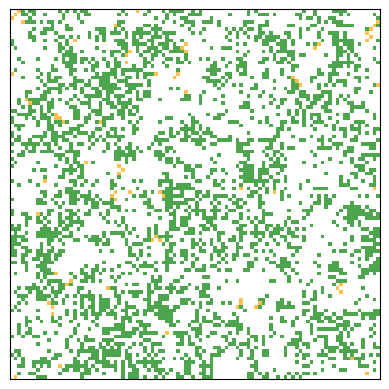

In [57]:
# Solution

# Here's an example:

fire = ForestFire(100)
fire.animate(frames=200)

In [58]:
# Solution

# Now let's see if the forest is fractal.

# I'll create a forest and run until steady state:

np.random.seed(22)
fire = ForestFire(200)
num_trees = []
for i in range(400):
    fire.step()
    num_trees.append(fire.num_trees())
    
plt.plot(num_trees)
decorate(xlabel='Time steps',
         ylabel='Number of trees')

In [59]:
# Solution

# Now let's see how the number of trees scales as we
# increase the size of the bounding box:

res = []
sizes = range(10, 100)
for i in sizes:
    res.append((i**2, fire.num_trees(i), fire.num_fires(i)))

In [60]:
# Solution

# Extracting the results:
    
cells, trees, fires = np.transpose(res)

In [61]:
# Solution

# And plotting them:

options = dict(linestyle='dashed', color='gray', alpha=0.7)
plt.plot(sizes, cells, label='cells', **options)
plt.plot(sizes, trees, '.', label='trees', color='green')
plt.plot(sizes, fires, label='fires', color='orange')
decorate(xlabel='Array size',
         ylabel='Cell Count',
         xscale='log', xlim=None, 
         yscale='log', ylim=None,
         loc='upper left')

In [62]:
# Solution

# And computing the fractal dimension:
    
from scipy.stats import linregress

for ys in [cells, trees]:
    params = linregress(np.log(sizes), np.log(ys))
    print(params[0])

2.0
1.9686713241762006


In [63]:
# Solution

# The fractal dimension varies from run to run, 
# but seems to be close to 2 most of the time.
# So it's not clear whether the forest is fractal or not.

[Think Complexity, 2nd Edition](https://greenteapress.com/wp/think-complexity-2e/)

Copyright 2016 [Allen B. Downey](https://allendowney.com)

Code license: [MIT License](https://mit-license.org/)

Text license: [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)